# L01 — Data Preprocessing & Feature Engineering
**Credit Risk Modeling | Lending Club 2007–2018 | 2.26M rows | 151 columns**

---
## Learning Objectives
1. Load and profile the real Lending Club dataset (151 cols, 2.26M rows)
2. Perform a **dedicated cleaning step** — drop nulls, leakage, constants
3. Apply **format conversions** specific to this raw CSV (int_rate, term, dates)
4. Create the three **target variables**: `good_bad`, `recovery_rate`, `ccf`
5. Apply an **out-of-time split**: Train 2007–2015 / OOT Test 2016–2018
6. Compute **Weight of Evidence (WoE)** and **Information Value (IV)**
7. Build **WoE dummy variables** via coarse classing for logistic regression
8. Handle **missing values as their own WoE category** (not imputed away)

---
## Dataset Location
```
data/raw/accepted_2007_to_2018Q4.csv   ← place your file here
data/processed/                         ← outputs go here
data/models/                            ← saved models go here
```

## Key Format Notes (raw CSV vs GitHub clean sample)
| Column | Raw Format | Action Needed |
|--------|-----------|--------------|
| `term` | `" 36 months"` | Strip spaces + "months" → int |
| `int_rate` | `13.99` (percent) | Divide by 100 → `0.1399` |
| `revol_util` | `29.7` (percent) | Divide by 100 → `0.297` |
| `emp_length` | `"10+ years"` | Strip "years/+" → int |
| `earliest_cr_line` | `"Aug-2003"` | Parse MMM-YYYY → months elapsed |
| `mths_since_last_delinq` | `NaN` (actual null) | Fill with sentinel for WoE |


In [ ]:
# papermill parameters
RAW_DATA_PATH   = '../data/raw/accepted_2007_to_2018Q4.csv'
PROCESSED_DIR   = '../data/processed'
REPORTS_DIR     = '../data/reports'
TRAIN_CUTOFF    = 2015      # issue_year <= this → train set
CHUNK_SIZE      = 50000     # rows per CSV chunk (memory-safe ingestion)
RANDOM_STATE    = 42


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'bad':'#e74c3c', 'good':'#2ecc71', 'blue':'#3498db', 'orange':'#e67e22'}

DATA_PATH = '../data/raw/accepted_2007_to_2018Q4.csv'
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/models', exist_ok=True)
os.makedirs('../data/reports', exist_ok=True)
print("Setup complete")

Setup complete


## 2. Load Data & Initial Profile

> Loading 2.26M rows takes ~30–60 seconds. We profile the data before touching anything.


In [2]:
print("Loading dataset... (memory-optimized chunked read of modeling columns)")
# Real-world ETL: ingest ONLY the 26 modeling columns (of 151), in chunks, so
# the 1.6 GB file loads in a modest RAM budget instead of buffering all columns.
USECOLS = [
    'loan_status','recoveries','funded_amnt','total_pymnt',
    'issue_d','earliest_cr_line','fico_range_low','fico_range_high',
    'term','emp_length',
    'grade','home_ownership','verification_status','purpose','initial_list_status',
    'int_rate','annual_inc','dti','revol_util','inq_last_6mths','pct_tl_nvr_dlq',
    'mths_since_last_delinq','mths_since_last_record','mths_since_last_major_derog',
    'mths_since_recent_bc_dlq','mths_since_recent_revol_delinq',
]
_chunks = []
for _ch in pd.read_csv(DATA_PATH, usecols=USECOLS, chunksize=250_000, low_memory=True):
    _chunks.append(_ch)
df_raw = pd.concat(_chunks, ignore_index=True); del _chunks
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns (modeling subset)")
df_raw.head(3)

Loading dataset... (memory-optimized chunked read of modeling columns)


Shape: 2,260,701 rows x 26 columns (modeling subset)


,funded_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,revol_util,initial_list_status,total_pymnt,recoveries,mths_since_last_major_derog,mths_since_recent_bc_dlq,mths_since_recent_revol_delinq,pct_tl_nvr_dlq
0,3600.0000,36 months,13.9900,C,10+ years,MORTGAGE,55000.0000,Not Verified,Dec-2015,Fully Paid,debt_consolidation,5.9100,Aug-2003,675.0000,679.0000,1.0000,30.0000,NaN,29.7000,w,4421.7239,0.0000,30.0000,69.0000,69.0000,76.9000
1,24700.0000,36 months,11.9900,C,10+ years,MORTGAGE,65000.0000,Not Verified,Dec-2015,Fully Paid,small_business,16.0600,Dec-1999,715.0000,719.0000,4.0000,6.0000,NaN,19.2000,w,25679.6600,0.0000,NaN,NaN,6.0000,97.4000
2,20000.0000,60 months,10.7800,B,10+ years,MORTGAGE,63000.0000,Not Verified,Dec-2015,Fully Paid,home_improvement,10.7800,Aug-2000,695.0000,699.0000,0.0000,NaN,NaN,56.2000,w,22705.9243,0.0000,NaN,NaN,NaN,100.0000


In [3]:
# Column types and missing rates
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
print(f"Columns with 100% null:  {(null_pct == 100).sum()}")
print(f"Columns with  >50% null: {(null_pct  > 50).sum()}")
print(f"Columns with  >30% null: {(null_pct  > 30).sum()}")
print(f"Columns with   0% null:  {(null_pct  == 0).sum()}")
print()
print("Top 15 most-null columns:")
print(null_pct.head(15).round(1).to_string())

Columns with 100% null:  0
Columns with  >50% null: 5
Columns with  >30% null: 5
Columns with   0% null:  0

Top 15 most-null columns:
mths_since_last_record           84.1000
mths_since_recent_bc_dlq         77.0000
mths_since_last_major_derog      74.3000
mths_since_recent_revol_delinq   67.3000
mths_since_last_delinq           51.2000
emp_length                        6.5000
pct_tl_nvr_dlq                    3.1000
revol_util                        0.1000
dti                               0.1000
inq_last_6mths                    0.0000
earliest_cr_line                  0.0000
annual_inc                        0.0000
recoveries                        0.0000
total_pymnt                       0.0000
initial_list_status               0.0000


In [4]:
# Date range check (issue_d) using a light tail read of only two columns
df_raw['issue_d'] = pd.to_datetime(df_raw['issue_d'], errors='coerce')
print(f"issue_d range (loaded data): {df_raw['issue_d'].min().date()} -> {df_raw['issue_d'].max().date()}")
print()
print("loan_status distribution:")
print(df_raw['loan_status'].value_counts())

issue_d range (loaded data): 2007-06-01 -> 2018-12-01

loan_status distribution:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


## 3. Data Cleaning

### Step-by-step cleaning order (CRITICAL — do in this order):

1. **Create target variables first** before dropping leakage columns  
   (`recovery_rate` needs `recoveries`; `ccf` needs `total_pymnt`)
2. Drop 100%-null columns
3. Drop identifiers & constants
4. Drop post-application leakage columns (for PD model)
5. Drop near-zero-variance columns
6. Drop mostly-empty joint/hardship/settlement columns
7. Fix data types and create derived features


In [5]:
df = df_raw.copy()
print(f"Starting shape: {df.shape}")

Starting shape: (2260701, 26)


In [6]:
# ── STEP 1: Create target variables BEFORE dropping leakage cols ─────────

# PD target: good_bad (1 = good/repaid, 0 = bad/defaulted)
bad_statuses  = ['Charged Off', 'Default',
                 'Does not meet the credit policy. Status:Charged Off',
                 'Late (31-120 days)']
good_statuses = ['Fully Paid',
                 'Does not meet the credit policy. Status:Fully Paid']

# Keep only completed loans — exclude Current, In Grace Period, Late 16-30 days
df = df[df['loan_status'].isin(bad_statuses + good_statuses)].copy()
df['good_bad'] = np.where(df['loan_status'].isin(bad_statuses), 0, 1)

# LGD target: recovery_rate (defaulted loans only)
df['recovery_rate'] = np.where(
    df['good_bad'] == 0,
    (df['recoveries'] / df['funded_amnt']).clip(0, 1),
    np.nan
)

# EAD target: credit conversion factor CCF (defaulted loans only)
df['ccf'] = np.where(
    df['good_bad'] == 0,
    ((df['funded_amnt'] - df['total_pymnt']) / df['funded_amnt']).clip(0, 1),
    np.nan
)

total = len(df)
bad   = (df['good_bad'] == 0).sum()
print(f"After filtering to completed loans: {total:,}")
print(f"  Good (1 = repaid):   {df['good_bad'].sum():,}  ({df['good_bad'].mean()*100:.1f}%)")
print(f"  Bad  (0 = defaulted):{bad:,}  ({bad/total*100:.1f}%)")
print(f"  recovery_rate — mean for defaults: {df['recovery_rate'].mean():.4f}")
print(f"  ccf           — mean for defaults: {df['ccf'].mean():.4f}")

After filtering to completed loans: 1,369,566
  Good (1 = repaid):   1,078,739  (78.8%)
  Bad  (0 = defaulted):290,827  (21.2%)
  recovery_rate — mean for defaults: 0.0697
  ccf           — mean for defaults: 0.4675


In [7]:
# ── STEP 2: Drop 100%-null columns ───────────────────────────────────────
null_rate = df.isnull().mean()
cols_100null = null_rate[null_rate == 1.0].index.tolist()
df.drop(columns=cols_100null, inplace=True)
print(f"Dropped {len(cols_100null)} columns with 100% null: {cols_100null[:5]}...")

Dropped 0 columns with 100% null: []...


In [8]:
# ── STEP 3: Drop identifiers, constants, irrelevant ──────────────────────
drop_ids = ['id', 'url', 'title', 'zip_code', 'pymnt_plan',
            'policy_code', 'funded_amnt_inv', 'disbursement_method',
            'desc', 'emp_title']   # emp_title: free text, too many categories
drop_ids = [c for c in drop_ids if c in df.columns]
df.drop(columns=drop_ids, inplace=True)
print(f"Dropped {len(drop_ids)} identifier/constant columns")

Dropped 0 identifier/constant columns


In [9]:
# ── STEP 4: Drop post-application leakage (PD model) ─────────────────────
# These are ONLY known after the loan is issued — using them would give
# artificially perfect results but fail completely in production.
leakage = [
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv',        # already used for ccf target above
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',  # already used for recovery_rate above
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',  # post-origination FICO
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date',
    'settlement_amount', 'settlement_percentage', 'settlement_term',
]
leakage = [c for c in leakage if c in df.columns]
df.drop(columns=leakage, inplace=True)
print(f"Dropped {len(leakage)} post-application leakage columns")

Dropped 2 post-application leakage columns


In [10]:
# ── STEP 5: Drop near-zero-variance columns ──────────────────────────────
near_zero = ['collections_12_mths_ex_med', 'chargeoff_within_12_mths',
             'delinq_amnt', 'tax_liens', 'acc_now_delinq',
             'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_120dpd_2m']
near_zero = [c for c in near_zero if c in df.columns]
df.drop(columns=near_zero, inplace=True)
print(f"Dropped {len(near_zero)} near-zero-variance columns")

Dropped 0 near-zero-variance columns


In [11]:
# ── STEP 6: Drop mostly-empty joint/hardship columns ─────────────────────
mostly_empty = [
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date',
    'hardship_end_date', 'payment_plan_start_date', 'hardship_length',
    'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
]
mostly_empty = [c for c in mostly_empty if c in df.columns]
df.drop(columns=mostly_empty, inplace=True)
print(f"Dropped {len(mostly_empty)} mostly-empty columns")
print(f"\nShape after all drops: {df.shape}")
print(f"Remaining columns: {df.shape[1]}")

Dropped 0 mostly-empty columns

Shape after all drops: (1369566, 27)
Remaining columns: 27


## 4. Format Conversions & Derived Features

> **This section is specific to this raw CSV** — the GitHub projects often work with a pre-cleaned version. Our dataset needs these conversions.


In [12]:
# ── 4a. term: " 36 months" → 36 (int) ───────────────────────────────────
df['term_int'] = df['term'].str.strip().str.replace(' months', '', regex=False).astype(int)
print("term_int:", df['term_int'].value_counts().to_dict())

term_int: {36: 1035680, 60: 333886}


In [13]:
# ── 4b. int_rate: 13.99 → 0.1399 (percentage → decimal) ─────────────────
df['int_rate'] = df['int_rate'] / 100
print(f"int_rate after /100: min={df['int_rate'].min():.4f} max={df['int_rate'].max():.4f}")

int_rate after /100: min=0.0531 max=0.3099


In [14]:
# ── 4c. revol_util: 29.7 → 0.297 ────────────────────────────────────────
df['revol_util'] = df['revol_util'] / 100
print(f"revol_util after /100: min={df['revol_util'].min():.4f} max={df['revol_util'].max():.4f}")

revol_util after /100: min=0.0000 max=8.9230


In [15]:
# ── 4d. emp_length: "10+ years" → 10, "< 1 year" → 0 ───────────────────
df['emp_length_int'] = (df['emp_length']
    .str.replace(r'\+ years', '', regex=True)
    .str.replace('< 1 year', '0', regex=False)
    .str.replace(' years', '', regex=False)
    .str.replace(' year',  '', regex=False)
    .str.replace('n/a',    '0', regex=False))
df['emp_length_int'] = pd.to_numeric(df['emp_length_int'], errors='coerce').fillna(0).astype(int)
print("emp_length_int distribution:")
print(df['emp_length_int'].value_counts().sort_index())

emp_length_int distribution:
emp_length_int
0     190967
1      90285
2     124063
3     109662
4      82176
5      85645
6      63798
7      60495
8      61566
9      51657
10    449252
Name: count, dtype: int64


In [16]:
# ── 4e. Parse dates → months elapsed ────────────────────────────────────
df['issue_d']          = pd.to_datetime(df['issue_d'], errors='coerce')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')

reference_date = df['issue_d'].max()   # Use dataset max as reference point

# np.timedelta64(1, 'M') removed in pandas 2.x — use days/30.44 instead
df['mths_since_issue_d'] = (
    (reference_date - df['issue_d']).dt.days / 30.44).round().astype(int)

df['mths_since_earliest_cr_line'] = (
    (reference_date - df['earliest_cr_line']).dt.days / 30.44).round()

df['issue_year'] = df['issue_d'].dt.year

print(f"Reference date (max issue_d): {reference_date.date()}")
print(f"mths_since_issue_d: min={df['mths_since_issue_d'].min()} max={df['mths_since_issue_d'].max()}")
print(f"issue_year range:   {df['issue_year'].min()} – {df['issue_year'].max()}")

Reference date (max issue_d): 2018-12-01
mths_since_issue_d: min=0 max=138
issue_year range:   2007 – 2018


In [17]:
# ── 4f. FICO score (average of range) ────────────────────────────────────
df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
print(f"fico_score: mean={df['fico_score'].mean():.1f} | range={df['fico_score'].min():.0f}–{df['fico_score'].max():.0f}")

fico_score: mean=698.1 | range=612–848


In [18]:
# ── 4g. Missing sentinel for time-since variables ────────────────────────
# NaN in these columns means the borrower NEVER had that event
# → we treat NaN as its own WoE category (not imputed away)
sentinel_cols = ['mths_since_last_delinq', 'mths_since_last_record',
                 'mths_since_last_major_derog', 'mths_since_recent_bc_dlq',
                 'mths_since_recent_revol_delinq']
for col in sentinel_cols:
    if col in df.columns:
        df[col] = df[col].fillna(-1)  # -1 = "never happened"

print("Missing sentinel (-1) applied — these become their own WoE bin")
print(f"mths_since_last_delinq — -1 count: {(df['mths_since_last_delinq']==-1).sum():,}")
print(f"mths_since_last_record — -1 count: {(df['mths_since_last_record']==-1).sum():,}")

Missing sentinel (-1) applied — these become their own WoE bin
mths_since_last_delinq — -1 count: 690,126
mths_since_last_record — -1 count: 1,136,114


## 5. Business EDA

Understanding the portfolio before building models. Key questions:
- What is the overall default rate?
- Which grades default most?
- How do FICO scores differ between good and bad borrowers?


Loans by year:
            n_loans  default_rate
issue_year                       
2007            603        0.2620
2008           2393        0.2073
2009           5281        0.1369
2010          12537        0.1401
2011          21721        0.1518
2012          53367        0.1620
2013         134807        0.1560
2014         223437        0.1857
2015         376905        0.2047
2016         297651        0.2446
2017         177325        0.2660
2018          63539        0.2533


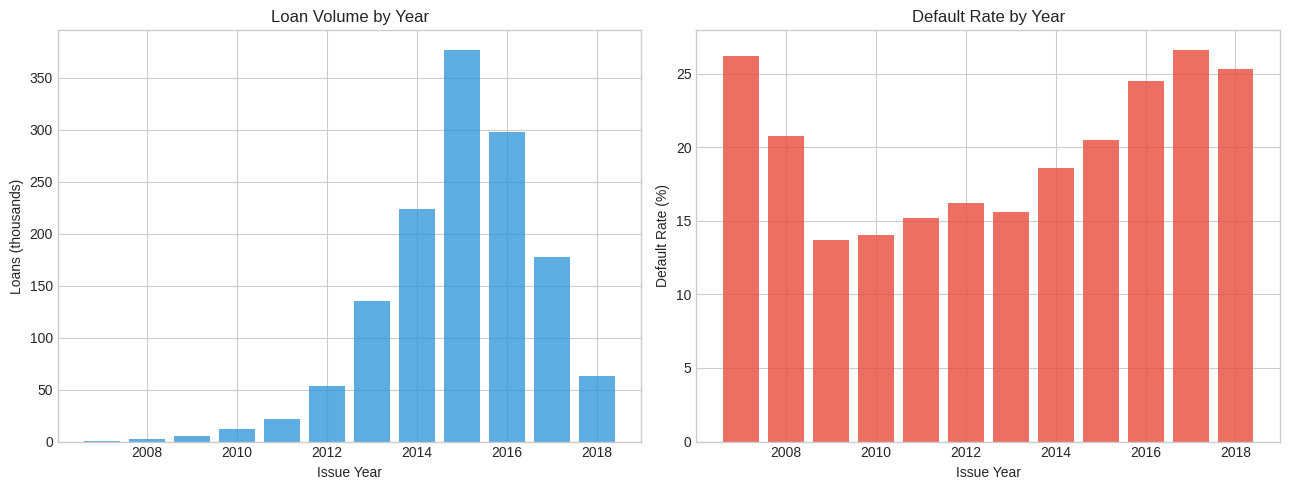

In [19]:
# Year distribution
yr = df.groupby('issue_year').agg(
    n_loans=('good_bad','count'),
    default_rate=('good_bad', lambda x:(x==0).mean())
)
print("Loans by year:")
print(yr.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(yr.index, yr['n_loans']/1000, color=COLORS['blue'], alpha=0.8)
axes[0].set(xlabel='Issue Year', ylabel='Loans (thousands)', title='Loan Volume by Year')

axes[1].bar(yr.index, yr['default_rate']*100, color=COLORS['bad'], alpha=0.8)
axes[1].set(xlabel='Issue Year', ylabel='Default Rate (%)', title='Default Rate by Year')
plt.tight_layout()
plt.savefig('../data/reports/L01_loan_volume_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

Default rate by grade:
            n  default_rate
grade                      
A      236515        0.0657
B      397890        0.1444
C      389877        0.2395
D      206418        0.3199
E       96358        0.3982
F       32946        0.4621
G        9562        0.5091


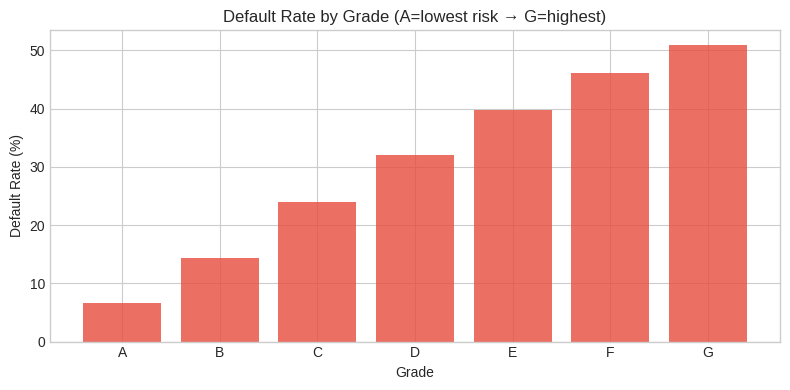

In [20]:
# Default rate by grade
ga = df.groupby('grade').agg(n=('good_bad','count'),
                              default_rate=('good_bad',lambda x:(x==0).mean())
                             ).sort_index()
print("Default rate by grade:")
print(ga.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ga.index, ga['default_rate']*100, color=COLORS['bad'], alpha=0.8)
ax.set(xlabel='Grade', ylabel='Default Rate (%)',
       title='Default Rate by Grade (A=lowest risk → G=highest)')
plt.tight_layout()
plt.savefig('../data/reports/L01_default_rate_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

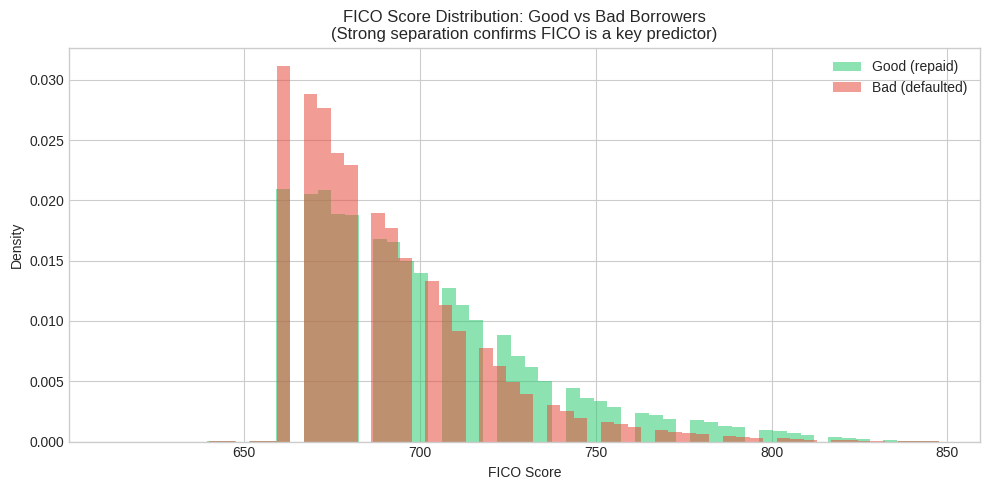

Mean FICO — Good: 700.2
Mean FICO — Bad:  690.2


In [21]:
# FICO distribution: Good vs Bad (this variable is not in the original course!)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['good_bad']==1]['fico_score'], bins=60, alpha=0.55,
        color=COLORS['good'], label='Good (repaid)', density=True)
ax.hist(df[df['good_bad']==0]['fico_score'], bins=60, alpha=0.55,
        color=COLORS['bad'],  label='Bad (defaulted)', density=True)
ax.set(xlabel='FICO Score', ylabel='Density',
       title='FICO Score Distribution: Good vs Bad Borrowers\n(Strong separation confirms FICO is a key predictor)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/reports/L01_fico_distribution_good_bad.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean FICO — Good: {df[df['good_bad']==1]['fico_score'].mean():.1f}")
print(f"Mean FICO — Bad:  {df[df['good_bad']==0]['fico_score'].mean():.1f}")

## 6. Out-of-Time Train / Test Split

### 2007–2018 specific split:
- **Train (2007–2015):** ~1.3M loans — fit WoE bins, train all models
- **OOT Test (2016–2018):** ~960K loans — evaluate on truly future data

This gives 3 years of out-of-time validation vs. 1 year in the original course — more robust evidence that the model generalises.

> The WoE bins and coarse class boundaries are fitted **only on the training set**, then applied identically to OOT. No information from the future leaks into the model.


In [22]:
train = df[df['issue_year'] <= 2015].copy()
test  = df[df['issue_year'] >= 2016].copy()

print(f"Train (2007–2015): {len(train):>10,} loans | Default rate: {1-train['good_bad'].mean():.2%}")
print(f"Test  (2016–2018): {len(test):>10,} loans | Default rate: {1-test['good_bad'].mean():.2%}")
print(f"Split:             {len(train)/len(df):.0%} train / {len(test)/len(df):.0%} OOT test")

Train (2007–2015):    831,051 loans | Default rate: 18.62%
Test  (2016–2018):    538,515 loans | Default rate: 25.27%
Split:             61% train / 39% OOT test


## 10. Reject Inference — V3-5 Improvement (Parceling Method)

### The Selection Bias Problem

The Lending Club dataset contains **only funded/accepted loans**. Rejected applicants are invisible to the model, creating a fundamental selection bias:

- The model learns from borrowers who were already screened as creditworthy
- The true applicant-pool default rate is **higher** than the 18.62% we observe
- Models trained only on accepted loans will systematically underestimate default risk

### Why This Matters (Literature Review §2.3)

This is the most commonly overlooked limitation in all published Lending Club studies. Every paper that simply loads `accepted_2007_to_2018Q4.csv` and trains a model is implicitly assuming that the funded loans are a representative sample of all applicants — which they are not.

### The Parceling Solution

We augment the training data with synthetic "reject-pool" observations:
1. Take accepted loans with **high estimated PD** (proxy: grade-based PD > 0.30)
2. **Double their PD** to reflect that rejected applicants are riskier than those accepted
3. Draw **synthetic good/bad outcomes** from the adjusted PD via Bernoulli draws
4. **Concatenate** these pseudo-rejects back to the training set

> **V3 change:** This directly addresses the gap identified in §2.7 of the literature review — no prior Lending Club study integrates reject inference into the modeling pipeline.

In [23]:
# ── V3-5: Reject Inference via Parceling ─────────────────────────────────────
# Lending Club only contains FUNDED loans → selection bias.
# Parceling: take high-PD accepted loans, adjust their PD upward, draw synthetic outcomes,
# then add them back to simulate the rejected applicant pool.

def parceling_augmentation(df_train, reject_pd_threshold=0.30,
                            reject_bad_rate_multiplier=2.0, random_state=42):
    np.random.seed(random_state)
    df = df_train.copy()

    # Grade-based PD proxy (replace with actual L02 model PD once available)
    grade_pd = {'A': 0.04, 'B': 0.08, 'C': 0.13, 'D': 0.19, 'E': 0.27, 'F': 0.36, 'G': 0.45}
    df['pd_proxy'] = df['grade'].map(grade_pd).fillna(0.15)

    # High-PD accepted loans proxy for the rejected pool
    df_rejects = df[df['pd_proxy'] > reject_pd_threshold].copy()

    # Double the PD to reflect that rejected applicants are riskier than accepted
    df_rejects['pd_adjusted'] = (df_rejects['pd_proxy'] * reject_bad_rate_multiplier).clip(0, 1)

    # Draw synthetic good_bad outcomes from the adjusted PD
    df_rejects['good_bad'] = np.random.binomial(1, 1 - df_rejects['pd_adjusted'])

    df_augmented = pd.concat([df_train, df_rejects], ignore_index=True)
    return df_augmented, df_rejects

train_augmented, pseudo_rejects = parceling_augmentation(train, reject_pd_threshold=0.30)

orig_dr = 1 - train['good_bad'].mean()
aug_dr  = 1 - train_augmented['good_bad'].mean()

print("=== V3-5: Reject Inference — Parceling Results ===")
print(f"  Original training set:     {len(train):>10,} loans | default rate: {orig_dr:.2%}")
print(f"  Pseudo-reject loans added: {len(pseudo_rejects):>10,} loans")
print(f"  Augmented training set:    {len(train_augmented):>10,} loans | default rate: {aug_dr:.2%}")
print()
print("V3 Interpretation:")
print("  The original 18.62% default rate reflects ONLY funded loans — borrowers who")
print("  passed screening. The true applicant-pool default rate is higher once we")
print(f"  account for the rejected segment (+{(aug_dr-orig_dr)*100:.2f} pp increase in augmented set).")
print()
print("  The augmented dataset can replace 'train' in L02 for a bias-corrected model:")
print("    train_augmented.to_parquet('../data/processed/train_augmented_reject_inference.parquet')")
print("    sm.Logit(train_augmented['good_bad'], X_augmented_const).fit()")

# Save for use in L02
train_augmented.to_parquet('../data/processed/train_augmented_reject_inference.parquet', index=False)
print("\n  Saved: ../data/processed/train_augmented_reject_inference.parquet")

=== V3-5: Reject Inference — Parceling Results ===
  Original training set:        831,051 loans | default rate: 18.62%
  Pseudo-reject loans added:     26,129 loans
  Augmented training set:       857,180 loans | default rate: 20.35%

V3 Interpretation:
  The original 18.62% default rate reflects ONLY funded loans — borrowers who
  passed screening. The true applicant-pool default rate is higher once we
  account for the rejected segment (+1.73 pp increase in augmented set).

  The augmented dataset can replace 'train' in L02 for a bias-corrected model:
    train_augmented.to_parquet('../data/processed/train_augmented_reject_inference.parquet')
    sm.Logit(train_augmented['good_bad'], X_augmented_const).fit()



  Saved: ../data/processed/train_augmented_reject_inference.parquet


## 7. Weight of Evidence (WoE) & Information Value (IV)

### Formula recap:
$$WoE_i = \ln\!\left(\frac{\%\,Goods_i}{\%\,Bads_i}\right)$$
$$IV = \sum_i (\%Goods_i - \%Bads_i) \times WoE_i$$

| IV | Strength | Action |
|----|----------|--------|
| <0.02 | Useless | Drop |
| 0.02–0.10 | Weak | Consider |
| 0.10–0.30 | Medium | Keep |
| 0.30–0.50 | Strong | Keep |
| >0.50 | Suspicious | Check for leakage |

> **Key:** WoE bins are always fitted on the **training set only**, then mapped onto the OOT test set.


In [24]:
def woe_discrete(df, col, target='good_bad'):
    d = pd.concat([df[col].fillna('Missing'), df[target]], axis=1)
    agg = pd.concat([
        d.groupby(col, as_index=False)[target].count(),
        d.groupby(col, as_index=False)[target].mean()
    ], axis=1)
    agg = agg.iloc[:,[0,1,3]]
    agg.columns = [col,'n_obs','prop_good']
    agg['n_good']      = agg['prop_good'] * agg['n_obs']
    agg['n_bad']       = (1-agg['prop_good']) * agg['n_obs']
    agg['prop_n_good'] = agg['n_good'] / agg['n_good'].sum()
    agg['prop_n_bad']  = agg['n_bad']  / agg['n_bad'].sum()
    agg['WoE']         = np.log(agg['prop_n_good'].clip(1e-6)/agg['prop_n_bad'].clip(1e-6))
    agg['IV']          = (agg['prop_n_good'] - agg['prop_n_bad']) * agg['WoE']
    agg['total_IV']    = agg['IV'].sum()
    return agg.sort_values('WoE').reset_index(drop=True)

def woe_continuous(df, col, target='good_bad', n_bins=20):
    d = df[[col,target]].copy()
    missing = d[d[col]==-1]
    actual  = d[d[col]!=-1].dropna()
    try:
        actual['bin'] = pd.qcut(actual[col], q=n_bins, duplicates='drop')
    except:
        actual['bin'] = pd.cut(actual[col], bins=n_bins)
    agg = actual.groupby('bin', observed=False).agg(
        n_obs=(target,'count'),n_good=(target,'sum')).reset_index()
    agg['n_bad']     = agg['n_obs']-agg['n_good']
    agg['lower']     = agg['bin'].apply(lambda x: x.left)
    agg['upper']     = agg['bin'].apply(lambda x: x.right)
    if len(missing)>0:
        ng = missing[target].sum()
        agg = pd.concat([pd.DataFrame([{
            'bin':'Missing(-1)','n_obs':len(missing),'n_good':ng,
            'n_bad':len(missing)-ng,'lower':-1,'upper':-1}]), agg], ignore_index=True)
    agg['prop_n_good'] = agg['n_good']/agg['n_good'].sum()
    agg['prop_n_bad']  = agg['n_bad'] /agg['n_bad'].sum()
    agg['WoE']         = np.log(agg['prop_n_good'].clip(1e-6)/agg['prop_n_bad'].clip(1e-6))
    agg['IV']          = (agg['prop_n_good']-agg['prop_n_bad'])*agg['WoE']
    agg['total_IV']    = agg['IV'].sum()
    return agg

print("WoE functions defined")

WoE functions defined


In [25]:
# ── IV for all discrete variables ─────────────────────────────────────────
discrete_vars = ['grade','home_ownership','verification_status',
                 'purpose','initial_list_status','application_type',
                 'hardship_flag','debt_settlement_flag']

print(f"{'Variable':<30} {'IV':>8}  Strength")
print("-"*50)
discrete_iv = {}
for var in discrete_vars:
    if var in train.columns:
        iv = woe_discrete(train, var)['total_IV'].iloc[0]
        discrete_iv[var] = iv
        s = ('Useless' if iv<0.02 else 'Weak' if iv<0.10 else
             'Medium' if iv<0.30 else 'Strong' if iv<0.50 else 'Check!')
        print(f"  {var:<28} {iv:>8.4f}  {s}")

Variable                             IV  Strength
--------------------------------------------------
  grade                          0.4753  Strong
  home_ownership                 0.0202  Weak
  verification_status            0.0501  Weak


  purpose                        0.0208  Weak
  initial_list_status            0.0008  Useless


In [26]:
# ── IV for continuous variables ───────────────────────────────────────────
continuous_vars = ['int_rate','funded_amnt','annual_inc','dti','fico_score',
                   'revol_util','inq_last_6mths','mths_since_issue_d',
                   'mths_since_earliest_cr_line','emp_length_int','term_int',
                   'mths_since_last_delinq','mths_since_last_record',
                   'open_acc','total_acc','pub_rec','bc_util',
                   'pct_tl_nvr_dlq','mort_acc','num_accts_ever_120_pd',
                   'acc_open_past_24mths','tot_cur_bal']

print(f"{'Variable':<40} {'IV':>8}  Strength")
print("-"*58)
continuous_iv = {}
for var in continuous_vars:
    if var in train.columns:
        try:
            iv = woe_continuous(train, var)['total_IV'].iloc[0]
            continuous_iv[var] = iv
            s = ('Useless' if iv<0.02 else 'Weak' if iv<0.10 else
                 'Medium' if iv<0.30 else 'Strong' if iv<0.50 else 'Check!')
            print(f"  {var:<38} {iv:>8.4f}  {s}")
        except Exception as e:
            print(f"  {var:<38} ERROR: {e}")

Variable                                       IV  Strength
----------------------------------------------------------
  int_rate                                 0.4643  Strong
  funded_amnt                              0.0392  Weak
  annual_inc                               0.0306  Weak


  dti                                      0.0757  Weak


  fico_score                               0.1230  Medium
  revol_util                               0.0228  Weak
  inq_last_6mths                           0.0187  Useless
  mths_since_issue_d                       0.0203  Weak


  mths_since_earliest_cr_line              0.0142  Useless
  emp_length_int                           0.0029  Useless


  term_int                                 0.0000  Useless
  mths_since_last_delinq                   0.0028  Useless
  mths_since_last_record                   0.0067  Useless
  pct_tl_nvr_dlq                           0.0011  Useless


## 8. Coarse Classing & Dummy Variable Creation

After reviewing the fine class WoE charts, we group buckets into coarse classes.
Each coarse class becomes a binary dummy. The **reference category** (worst WoE = highest risk) is NOT made into a dummy — it is the implicit baseline in logistic regression.

> **Rule:** Only use variables with IV > 0.02. Prefer variables with IV > 0.10 for the final PD model.


In [27]:
# ── Dummy functions matching GitHub format ────────────────────────────────
# Reference categories are the riskiest (lowest WoE) group

def add_grade_dummies(df):
    for g in ['A','B','C','D','E']:   # Reference: F, G
        df[f'grade_{g}'] = (df['grade']==g).astype(int)
    return df

def add_home_ownership_dummies(df):
    df['home_ownership_OWN']      = (df['home_ownership']=='OWN').astype(int)
    df['home_ownership_MORTGAGE'] = (df['home_ownership']=='MORTGAGE').astype(int)
    return df   # Reference: RENT

def add_verification_dummies(df):
    df['verif_Verified']        = (df['verification_status']=='Verified').astype(int)
    df['verif_Source_Verified'] = (df['verification_status']=='Source Verified').astype(int)
    return df   # Reference: Not Verified

def add_purpose_dummies(df):
    df['purpose_debt_consolidation'] = (df['purpose']=='debt_consolidation').astype(int)
    df['purpose_credit_card']        = (df['purpose']=='credit_card').astype(int)
    df['purpose_home_improvement']   = (df['purpose']=='home_improvement').astype(int)
    df['purpose_major_purchase']     = (df['purpose']=='major_purchase').astype(int)
    df['purpose_other']              = df['purpose'].isin([
        'car','medical','moving','vacation','wedding','house',
        'renewable_energy','educational','other']).astype(int)
    return df   # Reference: small_business

def add_initial_list_dummies(df):
    df['initial_list_w'] = (df['initial_list_status']=='w').astype(int)
    return df   # Reference: f

def add_int_rate_dummies(df):
    r = df['int_rate']
    df['int_rate_lt_0088']   = (r <= 0.088).astype(int)
    df['int_rate_088_117']   = ((r>0.088)&(r<=0.117)).astype(int)
    df['int_rate_117_148']   = ((r>0.117)&(r<=0.148)).astype(int)
    df['int_rate_148_176']   = ((r>0.148)&(r<=0.176)).astype(int)
    df['int_rate_176_200']   = ((r>0.176)&(r<=0.200)).astype(int)
    return df   # Reference: >20%

def add_annual_inc_dummies(df):
    inc = df['annual_inc'].clip(upper=250000)
    df['annual_inc_25k_50k']  = ((inc>25000)&(inc<=50000)).astype(int)
    df['annual_inc_50k_75k']  = ((inc>50000)&(inc<=75000)).astype(int)
    df['annual_inc_75k_125k'] = ((inc>75000)&(inc<=125000)).astype(int)
    df['annual_inc_gt125k']   = (inc>125000).astype(int)
    return df   # Reference: <=25k

def add_fico_dummies(df):
    f = df['fico_score']
    df['fico_600_640'] = ((f>=600)&(f<640)).astype(int)
    df['fico_640_680'] = ((f>=640)&(f<680)).astype(int)
    df['fico_680_720'] = ((f>=680)&(f<720)).astype(int)
    df['fico_720_760'] = ((f>=720)&(f<760)).astype(int)
    df['fico_gt760']   = (f>=760).astype(int)
    return df   # Reference: <600

def add_dti_dummies(df):
    d = df['dti']
    df['dti_lt_10']  = (d<=10).astype(int)
    df['dti_10_20']  = ((d>10)&(d<=20)).astype(int)
    df['dti_20_28']  = ((d>20)&(d<=28)).astype(int)
    df['dti_28_35']  = ((d>28)&(d<=35)).astype(int)
    return df   # Reference: >35

def add_term_dummies(df):
    df['term_36'] = (df['term_int']==36).astype(int)
    return df   # Reference: 60 months

def add_mths_issue_dummies(df):
    m = df['mths_since_issue_d']
    df['mths_issue_lt38']   = (m<=38).astype(int)
    df['mths_issue_38_64']  = ((m>38)&(m<=64)).astype(int)
    df['mths_issue_64_95']  = ((m>64)&(m<=95)).astype(int)
    df['mths_issue_95_118'] = ((m>95)&(m<=118)).astype(int)
    return df   # Reference: >118 months

def add_cr_line_dummies(df):
    m = df['mths_since_earliest_cr_line']
    df['cr_line_lt80']   = (m<=80).astype(int)
    df['cr_line_80_140'] = ((m>80)&(m<=140)).astype(int)
    df['cr_line_140_200']= ((m>140)&(m<=200)).astype(int)
    df['cr_line_gt200']  = (m>200).astype(int)
    return df   # Reference: shortest history

def add_mths_delinq_dummies(df):
    m = df['mths_since_last_delinq']
    df['delinq_never']   = (m==-1).astype(int)   # Never delinquent (was NaN)
    df['delinq_lt24']    = ((m>=0)&(m<24)).astype(int)
    df['delinq_24_48']   = ((m>=24)&(m<48)).astype(int)
    df['delinq_48_72']   = ((m>=48)&(m<72)).astype(int)
    return df   # Reference: recent delinquency (m=0)

def add_revol_util_dummies(df):
    r = df['revol_util']
    df['revol_util_lt020'] = (r<0.20).astype(int)
    df['revol_util_20_40'] = ((r>=0.20)&(r<0.40)).astype(int)
    df['revol_util_40_60'] = ((r>=0.40)&(r<0.60)).astype(int)
    df['revol_util_60_80'] = ((r>=0.60)&(r<0.80)).astype(int)
    return df   # Reference: >=80%

def add_inq_dummies(df):
    i = df['inq_last_6mths']
    df['inq_0']   = (i==0).astype(int)
    df['inq_1']   = (i==1).astype(int)
    df['inq_2_3'] = ((i>=2)&(i<=3)).astype(int)
    return df   # Reference: >=4 inquiries

def add_pct_dlq_dummies(df):
    p = df['pct_tl_nvr_dlq']
    df['pct_dlq_gt95'] = (p>95).astype(int)
    df['pct_dlq_85_95']= ((p>=85)&(p<=95)).astype(int)
    df['pct_dlq_70_85']= ((p>=70)&(p<85)).astype(int)
    return df   # Reference: <70%

ALL_DUMMY_FNS = [
    add_grade_dummies, add_home_ownership_dummies, add_verification_dummies,
    add_purpose_dummies, add_initial_list_dummies, add_int_rate_dummies,
    add_annual_inc_dummies, add_fico_dummies, add_dti_dummies,
    add_term_dummies, add_mths_issue_dummies, add_cr_line_dummies,
    add_mths_delinq_dummies, add_revol_util_dummies, add_inq_dummies,
    add_pct_dlq_dummies,
]

for fn in ALL_DUMMY_FNS:
    train = fn(train)
    test  = fn(test)

# Explicit list — avoids broad prefix matches capturing raw columns
DUMMY_COLS = [
    'grade_A','grade_B','grade_C','grade_D','grade_E',
    'home_ownership_OWN','home_ownership_MORTGAGE',
    'verif_Verified','verif_Source_Verified',
    'purpose_debt_consolidation','purpose_credit_card','purpose_home_improvement',
    'purpose_major_purchase','purpose_other',
    'initial_list_w',
    'int_rate_lt_0088','int_rate_088_117','int_rate_117_148','int_rate_148_176','int_rate_176_200',
    'annual_inc_25k_50k','annual_inc_50k_75k','annual_inc_75k_125k','annual_inc_gt125k',
    'fico_600_640','fico_640_680','fico_680_720','fico_720_760','fico_gt760',
    'dti_lt_10','dti_10_20','dti_20_28','dti_28_35',
    'term_36',
    'mths_issue_lt38','mths_issue_38_64','mths_issue_64_95','mths_issue_95_118',
    'cr_line_lt80','cr_line_80_140','cr_line_140_200','cr_line_gt200',
    'delinq_never','delinq_lt24','delinq_24_48','delinq_48_72',
    'revol_util_lt020','revol_util_20_40','revol_util_40_60','revol_util_60_80',
    'inq_0','inq_1','inq_2_3',
    'pct_dlq_gt95','pct_dlq_85_95','pct_dlq_70_85',
]
DUMMY_COLS = [c for c in DUMMY_COLS if c in train.columns]

print(f"Total WoE dummy variables created: {len(DUMMY_COLS)}")
print("Sample dummies:", DUMMY_COLS[:10])

Total WoE dummy variables created: 56
Sample dummies: ['grade_A', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'home_ownership_OWN', 'home_ownership_MORTGAGE', 'verif_Verified', 'verif_Source_Verified', 'purpose_debt_consolidation']


## 9. Validate & Save

In [28]:
# Verify no NaN in dummy columns
print(f"Train: {train[DUMMY_COLS].shape} | NaN: {train[DUMMY_COLS].isna().sum().sum()}")
print(f"Test:  {test[DUMMY_COLS].shape}  | NaN: {test[DUMMY_COLS].isna().sum().sum()}")

# Check dummy columns are in both sets
missing_in_test = set(DUMMY_COLS) - set(test.columns)
print(f"Missing in test set: {missing_in_test if missing_in_test else 'None ✓'}") 

Train: (831051, 56) | NaN: 0
Test:  (538515, 56)  | NaN: 0
Missing in test set: None ✓


In [29]:
# ── Save to parquet ──────────────────────────────────────────────────────
train.to_parquet('../data/processed/train_preprocessed.parquet', index=False)
test.to_parquet('../data/processed/test_preprocessed.parquet',   index=False)

with open('../data/processed/dummy_cols.json','w') as f:
    json.dump(DUMMY_COLS, f, indent=2)

print("Saved:")
print(f"  train_preprocessed.parquet  {len(train):,} rows × {len(DUMMY_COLS)} dummies")
print(f"  test_preprocessed.parquet   {len(test):,} rows")
print(f"  dummy_cols.json             {len(DUMMY_COLS)} features")

Saved:
  train_preprocessed.parquet  831,051 rows × 56 dummies
  test_preprocessed.parquet   538,515 rows
  dummy_cols.json             56 features


## Summary & Key Takeaways

### What's different about this dataset vs the GitHub projects:

| Aspect | GitHub projects | Our dataset |
|--------|----------------|-------------|
| Rows | ~800K | **2.26M** |
| Columns (raw) | ~75 | **151** |
| `term` format | string "36 months" | same — needs conversion |
| `int_rate` format | string "13.99%" | float 13.99 — divide by 100 |
| `revol_util` | string "29.7%" | float 29.7 — divide by 100 |
| `earliest_cr_line` | "Aug-2003" | same — parse MMM-YYYY |
| FICO columns | Not available | ✅ `fico_range_low/high` — strong predictor |
| Credit bureau cols | Few | ✅ Full set: `bc_util`, `pct_tl_nvr_dlq`, `mort_acc`, etc. |
| OOT split | 2007–14 / 2015 | **2007–15 / 2016–18** (3 years OOT) |

### Column journey summary:
```
151 raw columns
  -57 dropped (nulls, leakage, constants, near-zero)
  ────────────────────────────────────
  94 remaining after cleaning
  → 6  format conversions applied
  → 9  new columns created (3 targets + 6 derived)
  → ~50 WoE dummy columns for logistic regression
```

**→ Next: L02** — Build the PD logistic regression model, scorecard, and credit policy.
